In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader

# Dataset
The dataset used is the Oxford-IIIT Pet Dataset, which is a standard computer vision benchmark. It has 7,349 images for 37 breeds of cats and dogs.

Using device: cuda


100%|██████████| 792M/792M [00:30<00:00, 25.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.6MB/s]


Loaded 3680 images.


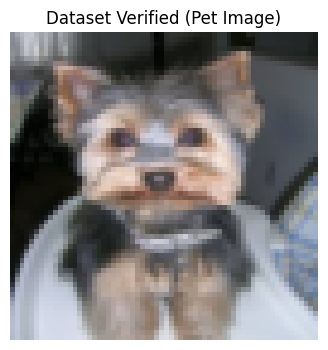

In [2]:
# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data Transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    # Use [0, 1] for VAE.
])

# Load Oxford-IIIT Pet Dataset (Official PyTorch Dataset)
print("Downloading Oxford-IIIT Pet Dataset (Reliable Official Source)...")
train_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Verify
print(f"Loaded {len(train_dataset)} images.")
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(4,4))
plt.imshow(images[0].permute(1, 2, 0).numpy())
plt.title("Dataset Verified (Pet Image)")
plt.axis('off')
plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder: 3 x 64 x 64 -> Latent Space
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),# 8x8
            nn.ReLU(),
            nn.Flatten()
        )

        # Mean and Log-Variance layers
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder: Latent Space -> 3 x 64 x 64
        self.decoder_input = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # 64x64
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        # Reshape to (Batch, Channels, Height, Width) for ConvTranspose
        de_input = self.decoder_input(z).view(-1, 128, 8, 8)
        return self.decoder(de_input), mu, logvar

model = VAE(latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def loss_function(recon_x, x, mu, logvar):
    # Reconstruction Loss (Binary Cross Entropy works well for pixels in [0,1])
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

Epoch 1 Average Loss: 8093.36


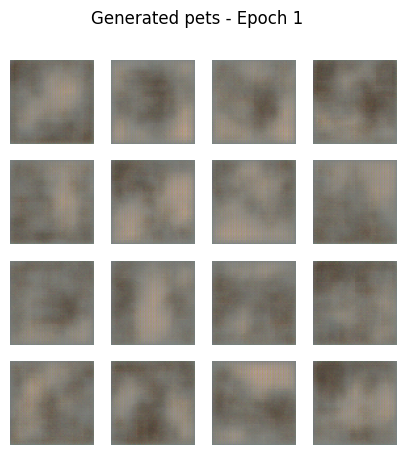

Epoch 2 Average Loss: 7520.35
Epoch 3 Average Loss: 7376.74
Epoch 4 Average Loss: 7320.43
Epoch 5 Average Loss: 7265.93


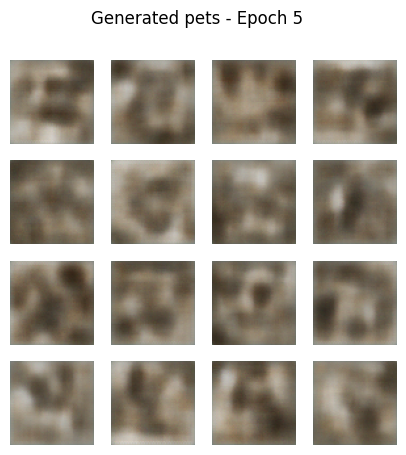

Epoch 6 Average Loss: 7226.77
Epoch 7 Average Loss: 7184.75
Epoch 8 Average Loss: 7153.98
Epoch 9 Average Loss: 7133.30
Epoch 10 Average Loss: 7115.30


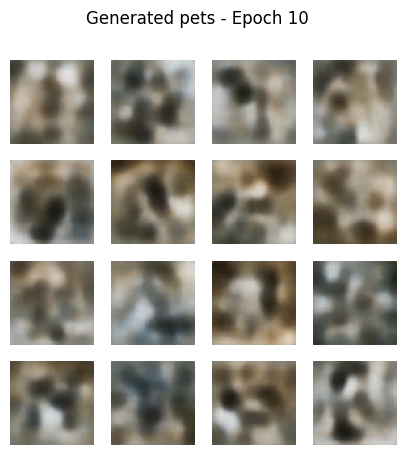

Epoch 11 Average Loss: 7097.95
Epoch 12 Average Loss: 7089.64
Epoch 13 Average Loss: 7075.44
Epoch 14 Average Loss: 7071.99
Epoch 15 Average Loss: 7060.50


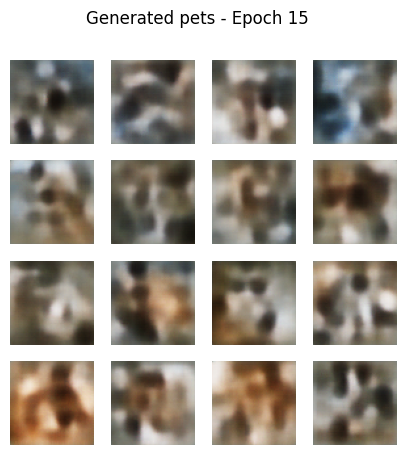

Epoch 16 Average Loss: 7056.98
Epoch 17 Average Loss: 7056.23
Epoch 18 Average Loss: 7044.36
Epoch 19 Average Loss: 7038.62
Epoch 20 Average Loss: 7039.06


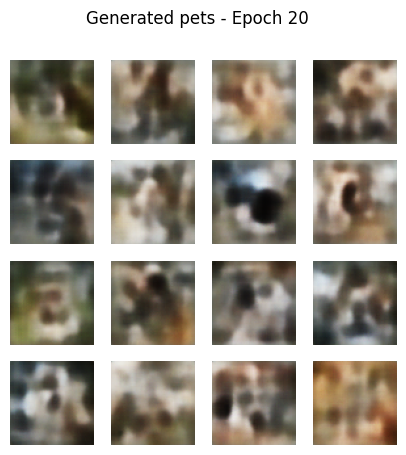

Epoch 21 Average Loss: 7028.92
Epoch 22 Average Loss: 7023.67
Epoch 23 Average Loss: 7022.53
Epoch 24 Average Loss: 7018.03
Epoch 25 Average Loss: 7011.54


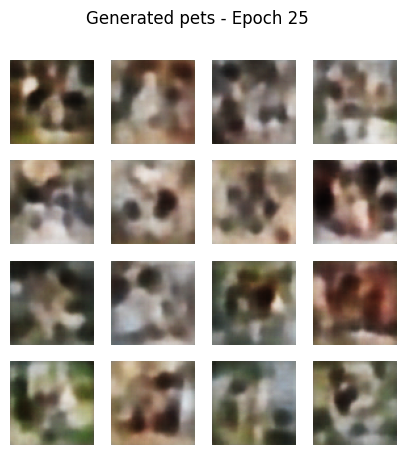

In [ ]:
def show_generated_images(model, epoch, num_images=16):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_images, model.latent_dim).to(device)
        sample = model.decoder(model.decoder_input(z).view(-1, 128, 8, 8)).cpu()

        grid_size = int(np.sqrt(num_images))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(5, 5))
        for i, ax in enumerate(axes.flat):
            ax.imshow(sample[i].permute(1, 2, 0))
            ax.axis('off')
        plt.suptitle(f"Generated pets - Epoch {epoch}")
        plt.show()

# --- Training Loop ---
epochs = 25
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch {epoch} Average Loss: {train_loss / len(train_loader.dataset):.2f}")

    if epoch % 5 == 0 or epoch == 1:
        show_generated_images(model, epoch)

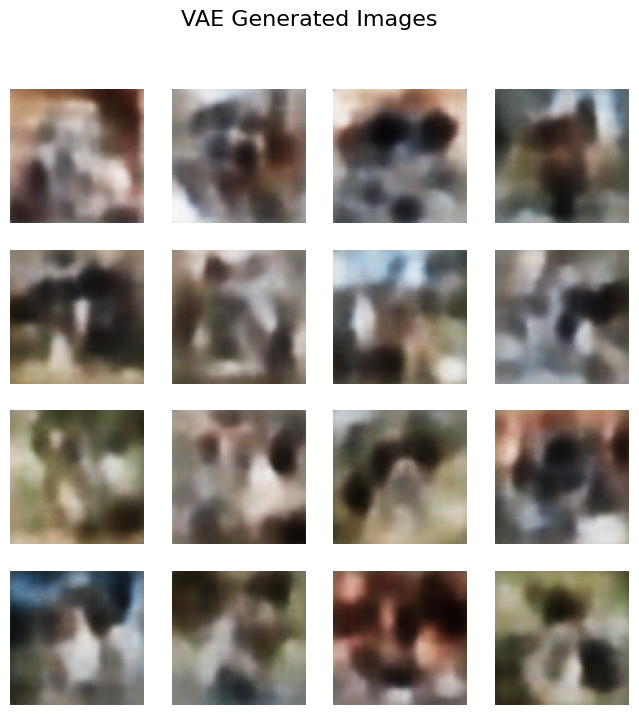

In [ ]:
import matplotlib.pyplot as plt

def generate_images(model, num_samples=16):
    model.eval()
    with torch.no_grad():
        # Simple random noise (normal distribution)
        z = torch.randn(num_samples, model.latent_dim).to(device)

        # Reshape z
        decoder_input = model.decoder_input(z).view(-1, 128, 8, 8)

        # Generate the images
        samples = model.decoder(decoder_input).cpu()

        # Plotting
        grid_size = int(np.sqrt(num_samples))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            img = samples[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.axis('off')

        plt.suptitle("VAE Generated Images", fontsize=16)
        plt.show()

# generate sample
generate_images(model)

# Part 2

In [ ]:
# Latent vector size
nz = 100

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # state size: 512 x 4 x 4
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # state size: 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # state size: 128 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # state size: 64 x 32 x 32
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh() # scale output to [-1, 1]
            # state size: 3 x 64 x 64
        )

    def forward(self, input):
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is 3 x 64 x 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 32 x 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 16 x 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 256 x 8 x 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 512 x 4 x 4
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [ ]:
transform_gan = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scales to [-1, 1]
])

gan_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_gan)
gan_loader = DataLoader(gan_dataset, batch_size=64, shuffle=True)

# Initialize
nz = 100
netG = Generator().to(device)
netD = Discriminator().to(device)

# Loss and Optimizers
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

Starting GAN Training...
[1/50] Loss_D: 0.3936 Loss_G: 4.0250


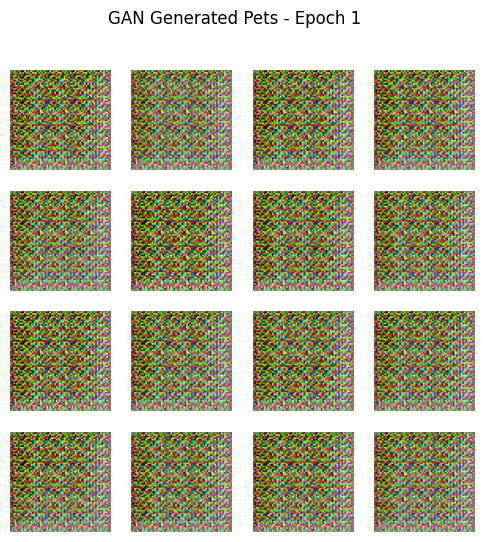

[2/50] Loss_D: 0.7883 Loss_G: 3.6328
[3/50] Loss_D: 0.5713 Loss_G: 3.1415
[4/50] Loss_D: 1.5527 Loss_G: 1.1053
[5/50] Loss_D: 0.1995 Loss_G: 4.0676


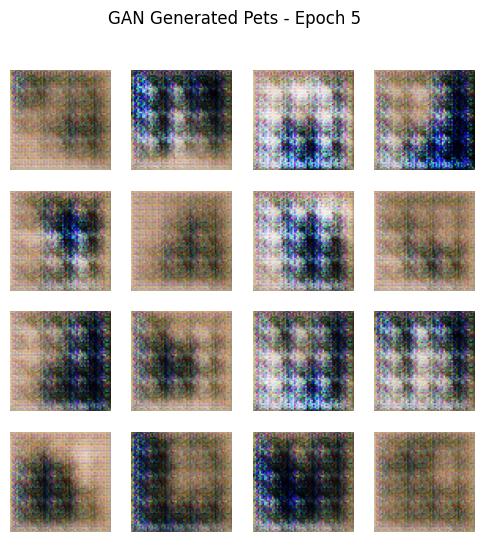

[6/50] Loss_D: 0.7028 Loss_G: 3.0350
[7/50] Loss_D: 0.5988 Loss_G: 2.9690
[8/50] Loss_D: 0.1819 Loss_G: 2.5912
[9/50] Loss_D: 0.8228 Loss_G: 2.5593
[10/50] Loss_D: 0.3133 Loss_G: 4.5555


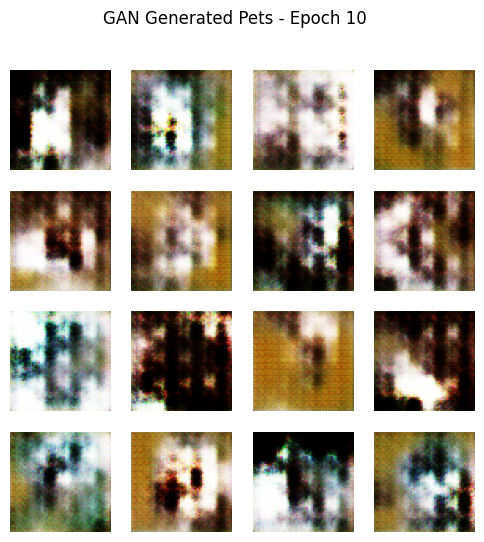

[11/50] Loss_D: 0.4551 Loss_G: 3.2145
[12/50] Loss_D: 1.2082 Loss_G: 1.0389
[13/50] Loss_D: 0.6594 Loss_G: 3.4629
[14/50] Loss_D: 0.3296 Loss_G: 2.5649
[15/50] Loss_D: 0.4612 Loss_G: 4.2902


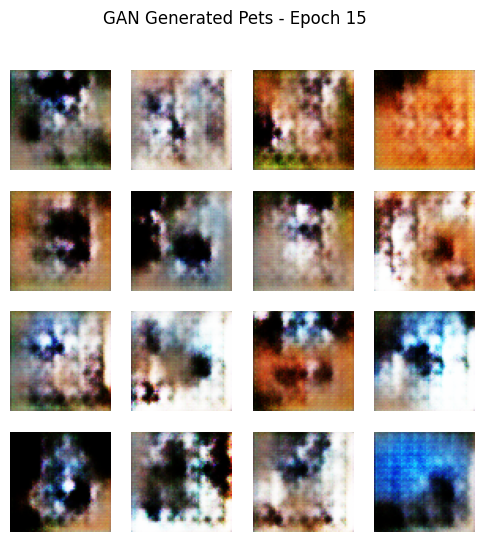

[16/50] Loss_D: 0.5448 Loss_G: 2.2705
[17/50] Loss_D: 0.6770 Loss_G: 2.8495
[18/50] Loss_D: 0.3701 Loss_G: 4.1177
[19/50] Loss_D: 0.7587 Loss_G: 2.6254
[20/50] Loss_D: 1.0502 Loss_G: 3.1520


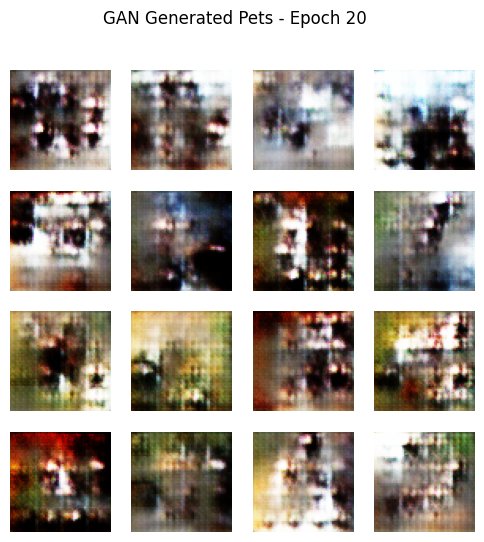

[21/50] Loss_D: 0.4039 Loss_G: 3.9225
[22/50] Loss_D: 1.0521 Loss_G: 3.8074
[23/50] Loss_D: 0.2860 Loss_G: 3.3264
[24/50] Loss_D: 0.4365 Loss_G: 3.3956
[25/50] Loss_D: 1.1044 Loss_G: 0.9864


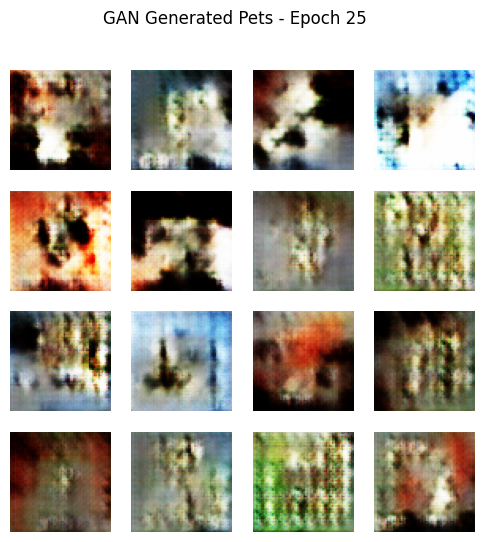

[26/50] Loss_D: 0.4150 Loss_G: 4.5529
[27/50] Loss_D: 0.2666 Loss_G: 2.5654
[28/50] Loss_D: 0.3628 Loss_G: 4.9980
[29/50] Loss_D: 0.5006 Loss_G: 3.0241
[30/50] Loss_D: 0.6499 Loss_G: 4.6539


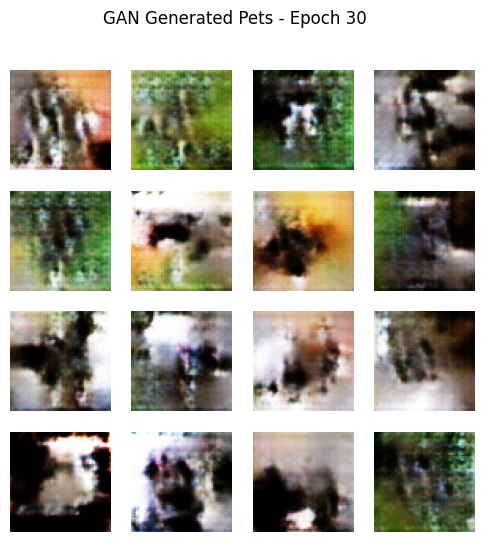

[31/50] Loss_D: 1.2110 Loss_G: 3.7927
[32/50] Loss_D: 0.5846 Loss_G: 2.9908
[33/50] Loss_D: 0.2588 Loss_G: 3.3355
[34/50] Loss_D: 0.4232 Loss_G: 4.2791
[35/50] Loss_D: 0.5348 Loss_G: 4.2123


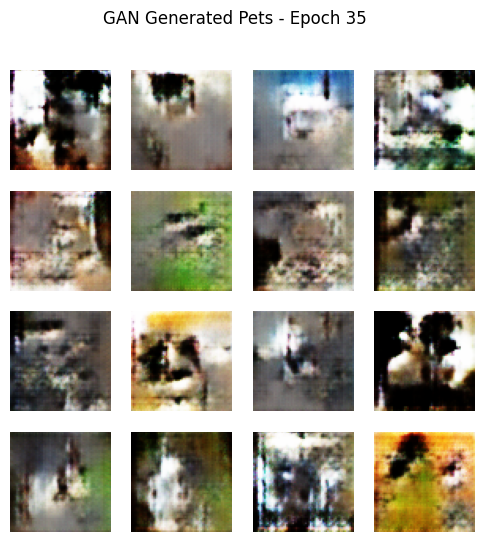

[36/50] Loss_D: 0.5408 Loss_G: 5.3391
[37/50] Loss_D: 0.2780 Loss_G: 4.4511
[38/50] Loss_D: 0.4081 Loss_G: 3.6443
[39/50] Loss_D: 0.7008 Loss_G: 2.9486
[40/50] Loss_D: 0.8452 Loss_G: 1.6708


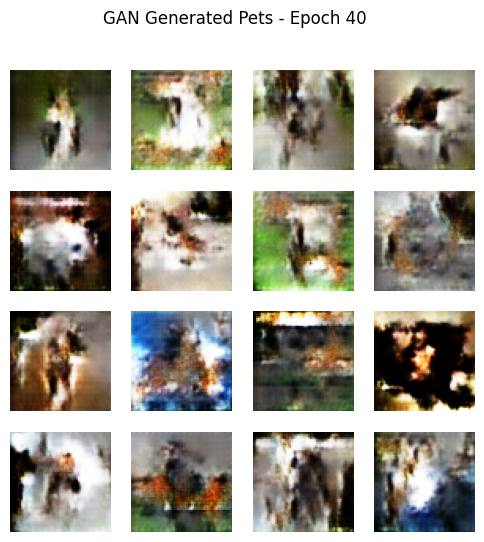

[41/50] Loss_D: 0.3738 Loss_G: 4.6655
[42/50] Loss_D: 0.4612 Loss_G: 4.5420
[43/50] Loss_D: 0.8916 Loss_G: 5.9434
[44/50] Loss_D: 0.2083 Loss_G: 4.6648
[45/50] Loss_D: 0.7129 Loss_G: 1.3335


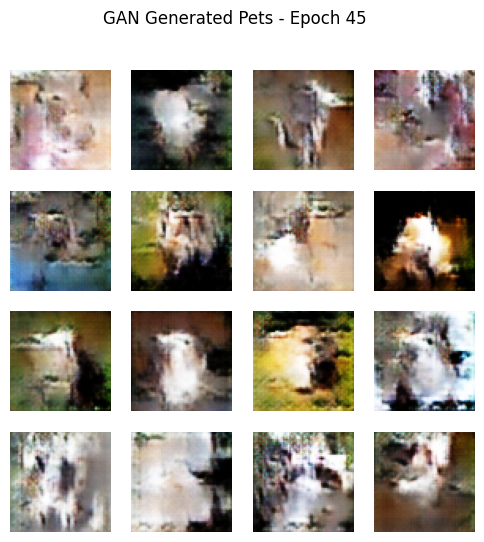

[46/50] Loss_D: 0.2339 Loss_G: 5.2848
[47/50] Loss_D: 0.2785 Loss_G: 3.4980
[48/50] Loss_D: 0.5964 Loss_G: 2.2939
[49/50] Loss_D: 0.4493 Loss_G: 5.1372
[50/50] Loss_D: 0.4763 Loss_G: 3.2983


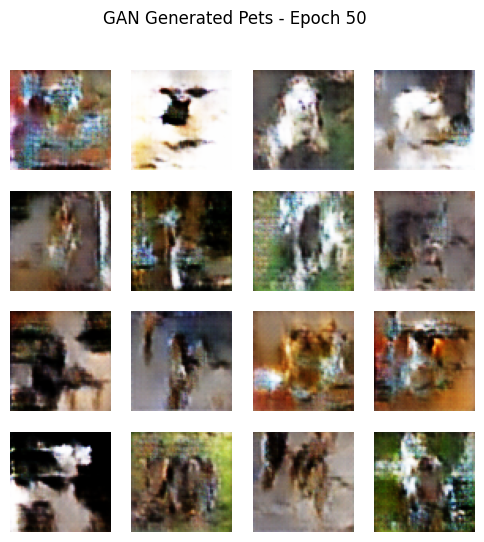

In [ ]:
epochs = 50
print("Starting GAN Training...")

for epoch in range(epochs):
    for i, (data, _) in enumerate(gan_loader):
        # maximize log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()
        real = data.to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), 1.0, device=device) # 'Real' = 1

        output = netD(real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0) # 'Fake' = 0
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        optimizerD.step()

        # maximize log(D(G(z)))
        netG.zero_grad()
        label.fill_(1.0) # Generator wants fakes to be labeled as 1
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    print(f'[{epoch+1}/{epochs}] Loss_D: {errD_real+errD_fake:.4f} Loss_G: {errG:.4f}')

    # Progress Display
    if (epoch + 1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            # Standard noise for consistent monitoring
            test_noise = torch.randn(16, nz, 1, 1, device=device)
            sample = netG(test_noise).cpu()
            # Denormalize: [-1, 1] -> [0, 1]
            sample = sample * 0.5 + 0.5

            fig, ax = plt.subplots(4, 4, figsize=(6,6))
            for idx, a in enumerate(ax.flat):
                a.imshow(sample[idx].permute(1, 2, 0))
                ax_img = sample[idx].permute(1, 2, 0).numpy()
                a.imshow(np.clip(ax_img, 0, 1)) # Ensure pixels are valid
                a.axis('off')
            plt.suptitle(f"GAN Generated Pets - Epoch {epoch+1}")
            plt.show()

The VAE produced stables images but they were blurry. This happened because it optimizes for the average likelyhood by using the MSE loss. It does not prioritize sharp details, just the general color and shape of the original data.

The GAN on the other hand gave sharper images and produced some of the features present in the training images but sparsely. The GAN was more unstable but the images were more understandable in some ways.

## Data Preprocessing
Part of the reason the images were not good, is because I had to lower the dimensionality so that the algorithm would run within a reasonable amount of time.